# Multivariate Predictor EDA for Hybrid Risk Models

This notebook studies candidate predictors for hybrid VaR/ES forecasting. It connects feature engineering, correlation diagnostics, LSTM-based tail forecasts, regime detection, and economic evaluation.

## Notebook flow

1. Load the transformed MASI feature set.
2. Inspect candidate predictors and multivariate relationships.
3. Train the LSTM VaR plus Ridge ES pipeline through reusable functions.
4. Compare out-of-sample forecasts and regimes.
5. Evaluate the economic behavior of the final allocation rules.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


Libraries imported successfully.


In [2]:
import pandas as pd

df = pd.read_csv("../../data/processed/transformed/masi_transformed.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)
print(df.head())

        date     open      high      low     close  volume  change_pct dataset  simple_return  log_return  log_open_close  log_high_low  price_range_pct  \
0 2007-01-02  9458.69   9514.92  9418.46   9482.63     NaN        0.03    MASI            NaN         NaN        0.002528      0.010189         0.010172   
1 2007-01-03  9476.92   9625.38  9476.54   9625.38     NaN        1.51    MASI       0.015054    0.014942        0.015544      0.015584         0.015463   
2 2007-01-04  9641.22   9780.28  9629.58   9780.28     NaN        1.61    MASI       0.016093    0.015965        0.014320      0.015529         0.015409   
3 2007-01-05  9810.59   9984.81  9809.23   9933.29     NaN        1.56    MASI       0.015645    0.015524        0.012429      0.017741         0.017676   
4 2007-01-08  9960.51  10049.33  9956.31  10023.46     NaN        0.91    MASI       0.009078    0.009037        0.006300      0.009299         0.009280   

   close_to_open_ratio  volume_log_change  log_return_mean_5  l

In [3]:
import pandas as pd

# On part d'une copie triÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â©e par date pour garantir le bon ordre temporel
df_masi = df.copy()
df_masi["date"] = pd.to_datetime(df_masi["date"])
df_masi = df_masi.sort_values("date").reset_index(drop=True)

# Si tu veux travailler uniquement sur le MASI
df_masi = df_masi[df_masi["dataset"] == "MASI"].copy()

# Construction des features sans leakage
# Chaque feature ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â  la date t utilise uniquement l'information disponible jusqu'ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â  t
df_features = pd.DataFrame()
df_features["date"] = df_masi["date"]
df_features["log_return"] = df_masi["log_return"]
df_features["log_return_std_5"] = df_masi["log_return"].rolling(window=5).std()
df_features["log_return_std_21"] = df_masi["log_return"].rolling(window=21).std()
df_features["log_return_mean_21"] = df_masi["log_return"].rolling(window=21).mean()
df_features["log_high_low"] = df_masi["log_high_low"]
df_features["log_return_rolling_skew_20"] = df_masi["log_return"].rolling(window=20).skew()

# Supprimer les NaN provenant uniquement des dÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â©calages / rolling windows du dÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â©but
# La fenÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Âªtre la plus longue est 21, donc les premiÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¨res lignes seront inexploitables
df_features = df_features.dropna().reset_index(drop=True)

# VÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â©rification
print(df_features.shape)
print(df_features.head())
print(df_features.tail())


(4763, 7)
        date  log_return  log_return_std_5  log_return_std_21  log_return_mean_21  log_high_low  log_return_rolling_skew_20
0 2007-02-01   -0.024015          0.015910           0.010312            0.003506      0.030262                   -0.845374
1 2007-02-02    0.005631          0.014604           0.009991            0.003063      0.007185                   -0.925371
2 2007-02-05    0.004561          0.013418           0.009556            0.002520      0.011896                   -1.040712
3 2007-02-06    0.010379          0.013569           0.009267            0.002275      0.013924                   -1.027447
4 2007-02-07   -0.005498          0.013704           0.009280            0.001583      0.008182                   -1.021646
           date  log_return  log_return_std_5  log_return_std_21  log_return_mean_21  log_high_low  log_return_rolling_skew_20
4758 2026-03-13   -0.017755          0.022968           0.021803           -0.004805      0.020059                   -0

Shape du DataFrame final : (4763, 7)

Apercu :
        date  log_return  log_return_std_5  log_return_std_21  log_return_mean_21  log_high_low  log_return_rolling_skew_20
0 2007-02-01   -0.024015          0.015910           0.010312            0.003506      0.030262                   -0.845374
1 2007-02-02    0.005631          0.014604           0.009991            0.003063      0.007185                   -0.925371
2 2007-02-05    0.004561          0.013418           0.009556            0.002520      0.011896                   -1.040712
3 2007-02-06    0.010379          0.013569           0.009267            0.002275      0.013924                   -1.027447
4 2007-02-07   -0.005498          0.013704           0.009280            0.001583      0.008182                   -1.021646

Statistiques descriptives :
                             count      mean       std       min       25%       50%       75%       max  skewness   kurtosis
log_return                  4763.0  0.000105  0.007739

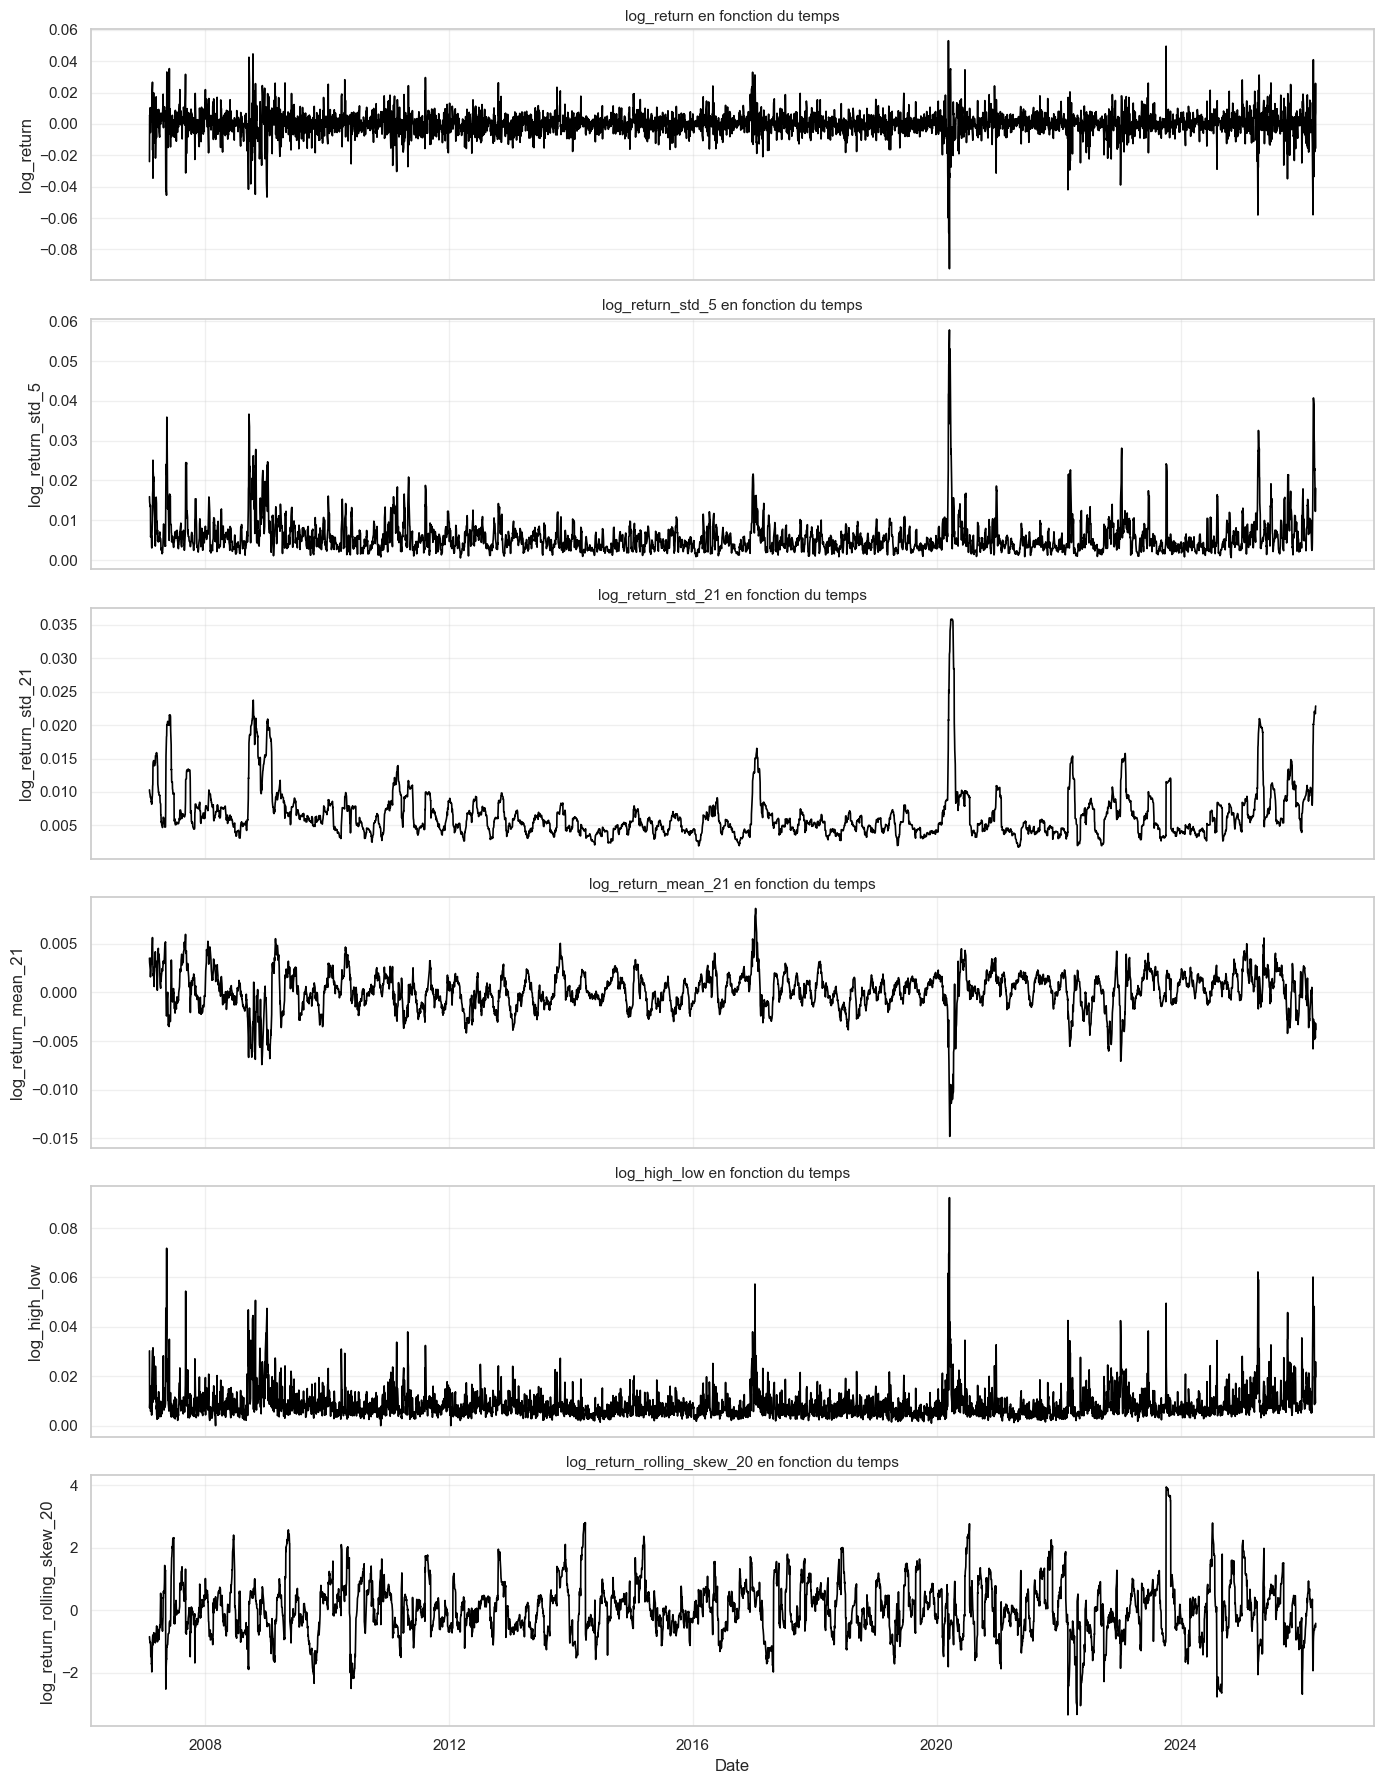

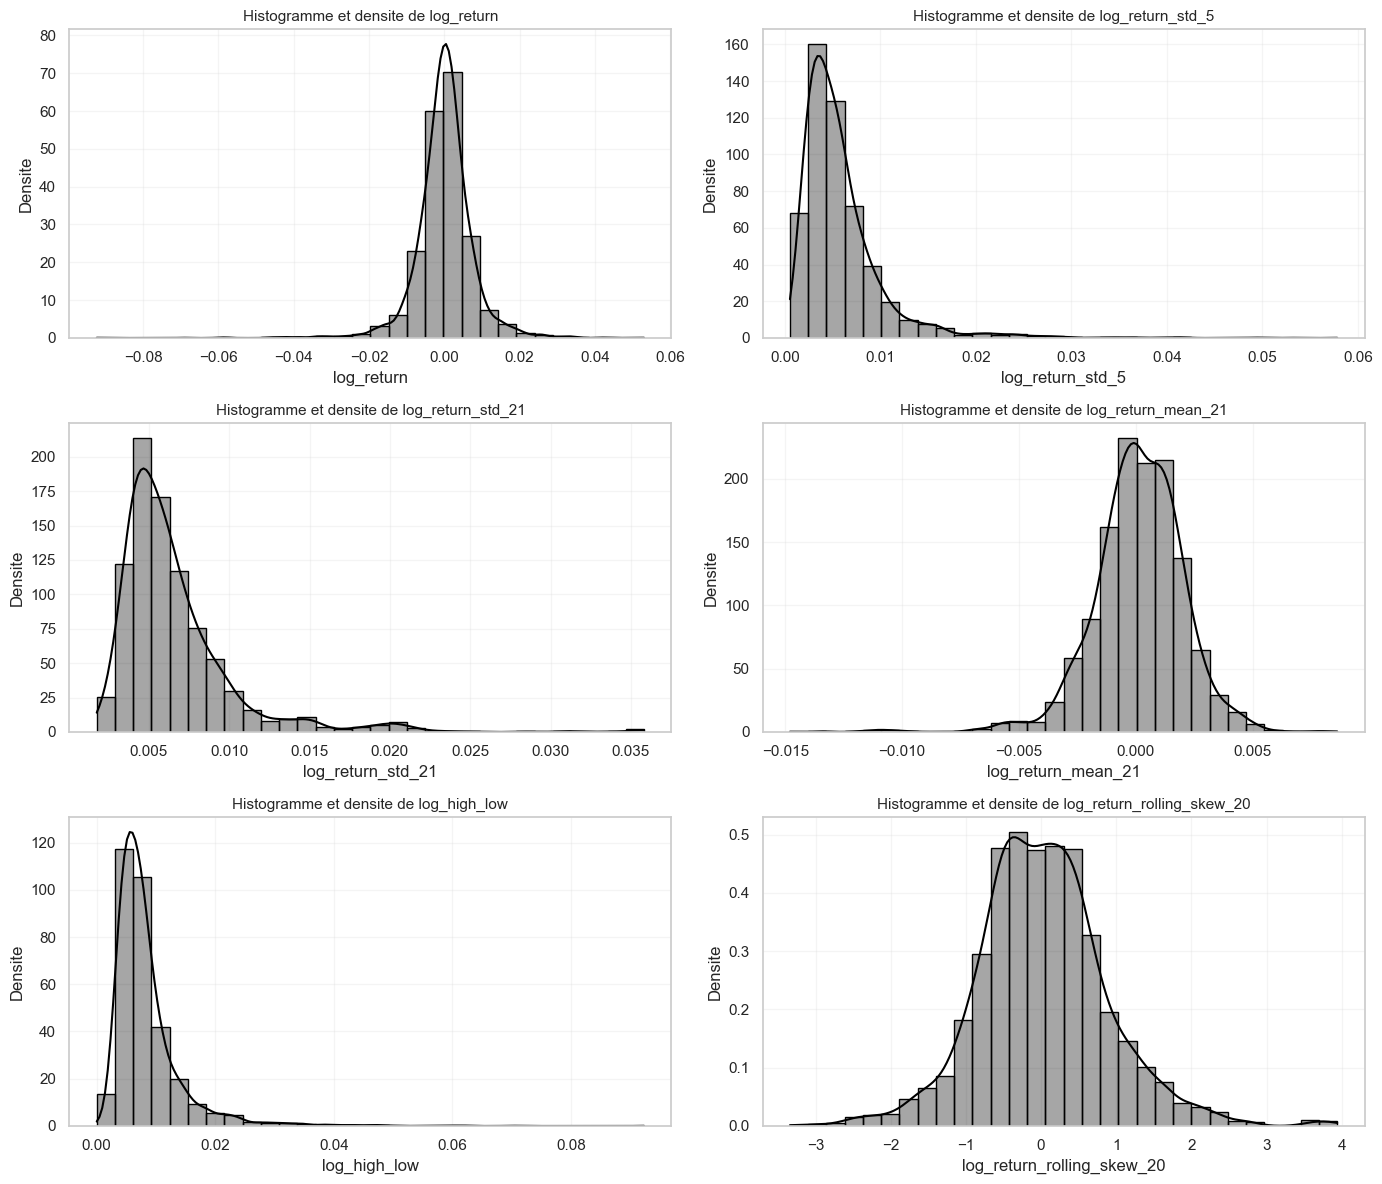

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# 1. Construction du DataFrame de features sans leakage
# =========================================================

df_masi = df.copy()
df_masi["date"] = pd.to_datetime(df_masi["date"])
df_masi = df_masi.sort_values("date").reset_index(drop=True)

# Si le dataset contient plusieurs actifs, on garde uniquement MASI
if "dataset" in df_masi.columns:
    df_masi = df_masi[df_masi["dataset"] == "MASI"].copy()

df_features = pd.DataFrame({
    "date": df_masi["date"],
    "log_return": df_masi["log_return"],
    "log_return_std_5": df_masi["log_return"].rolling(window=5).std(),
    "log_return_std_21": df_masi["log_return"].rolling(window=21).std(),
    "log_return_mean_21": df_masi["log_return"].rolling(window=21).mean(),
    "log_high_low": df_masi["log_high_low"],
    "log_return_rolling_skew_20": df_masi["log_return"].rolling(window=20).skew(),
})

# Suppression des NaN dus aux rolling windows
df_features = df_features.dropna().reset_index(drop=True)

print("Shape du DataFrame final :", df_features.shape)
print("\nApercu :")
print(df_features.head())

# =========================================================
# 2. Mini-EDA
# =========================================================

sns.set_style("whitegrid")

eda_features = [
    "log_return",
    "log_return_std_5",
    "log_return_std_21",
    "log_return_mean_21",
    "log_high_low",
    "log_return_rolling_skew_20",
]

# =========================================================
# A. Statistiques descriptives
# =========================================================

desc_stats = df_features[eda_features].describe().T
desc_stats["skewness"] = df_features[eda_features].skew()
desc_stats["kurtosis"] = df_features[eda_features].kurtosis()

print("\nStatistiques descriptives :")
print(desc_stats)

# =========================================================
# B. SÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â©ries temporelles
# =========================================================

n_features = len(eda_features)
fig, axes = plt.subplots(n_features, 1, figsize=(14, 3 * n_features), sharex=True)

for i, feature in enumerate(eda_features):
    axes[i].plot(df_features["date"], df_features[feature], color="black", linewidth=1.2)
    axes[i].set_title(f"{feature} en fonction du temps", fontsize=11)
    axes[i].set_ylabel(feature)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

# =========================================================
# C. Histogrammes + densitÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â©
# =========================================================

n_cols = 2
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(eda_features):
    sns.histplot(
        df_features[feature],
        bins=30,
        stat="density",
        kde=True,
        color="black",
        edgecolor="black",
        alpha=0.35,
        ax=axes[i]
    )
    axes[i].set_title(f"Histogramme et densite de {feature}", fontsize=11)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Densite")
    axes[i].grid(True, alpha=0.2)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Matrice de correlation :
                            log_return  log_return_std_5  log_return_std_21  log_return_mean_21  log_high_low  log_return_rolling_skew_20
log_return                       1.000            -0.023             -0.036               0.236        -0.082                       0.097
log_return_std_5                -0.023             1.000              0.663              -0.225         0.650                      -0.093
log_return_std_21               -0.036             0.663              1.000              -0.298         0.498                      -0.082
log_return_mean_21               0.236            -0.225             -0.298               1.000        -0.187                       0.280
log_high_low                    -0.082             0.650              0.498              -0.187         1.000                      -0.100
log_return_rolling_skew_20       0.097            -0.093             -0.082               0.280        -0.100                       1.000


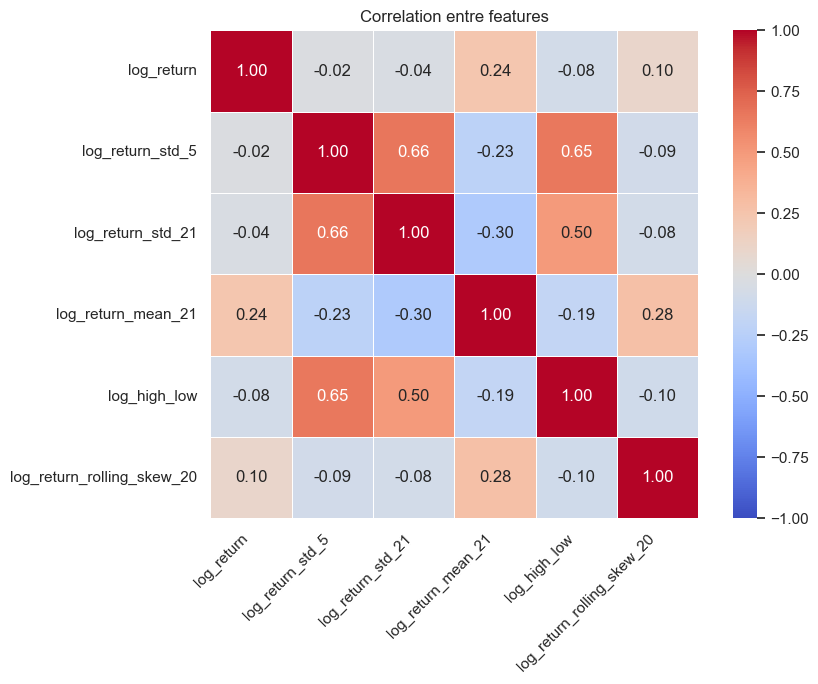

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Features a analyser
corr_features = [
    "log_return",
    "log_return_std_5",
    "log_return_std_21",
    "log_return_mean_21",
    "log_high_low",
    "log_return_rolling_skew_20",
]

# Matrice de correlation
corr_matrix = df_features[corr_features].corr()

# Affichage numerique
print("Matrice de correlation :")
print(corr_matrix.round(3))

# Heatmap coloree
plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True,
    cbar=True
)

plt.title("Correlation entre features")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [6]:
df_model = df_features[
    [
        "date",
        "log_return",
        "log_return_std_5",
        "log_return_std_21",
        "log_return_mean_21",
        "log_return_rolling_skew_20",
    ]
].copy()

print(df_model.shape)
print(df_model.head())


(4763, 6)
        date  log_return  log_return_std_5  log_return_std_21  log_return_mean_21  log_return_rolling_skew_20
0 2007-02-01   -0.024015          0.015910           0.010312            0.003506                   -0.845374
1 2007-02-02    0.005631          0.014604           0.009991            0.003063                   -0.925371
2 2007-02-05    0.004561          0.013418           0.009556            0.002520                   -1.040712
3 2007-02-06    0.010379          0.013569           0.009267            0.002275                   -1.027447
4 2007-02-07   -0.005498          0.013704           0.009280            0.001583                   -1.021646


In [7]:
selected_features = [
    "log_return_std_21",
    "log_return",
    "log_return_mean_21",
    "log_return_std_5",
]

required_columns = ["date"] + selected_features + ["target"]

# Si df_model a ete cree avant la colonne target, on le reconstruit proprement
if "target" not in df_model.columns:
    df_model = df_features.copy()
    if "target" not in df_model.columns:
        df_model["target"] = df_model["log_return"].shift(-1)
    df_model = df_model.dropna().reset_index(drop=True)

missing_columns = [col for col in required_columns if col not in df_model.columns]
if missing_columns:
    raise KeyError(f"Colonnes manquantes dans df_model: {missing_columns}")

df_model_final = df_model[required_columns].copy()

# Split chronologique fixe
train_size = 3998
test_size = 764

df_train = df_model_final.iloc[:train_size].copy()
df_test = df_model_final.iloc[train_size:train_size + test_size].copy()

X_train = df_train[selected_features]
y_train = df_train["target"]

X_test = df_test[selected_features]
y_test = df_test["target"]

print("Train shape :", df_train.shape)
print("Test shape  :", df_test.shape)
print("Periode train :", df_train["date"].min(), "->", df_train["date"].max())
print("Periode test  :", df_test["date"].min(), "->", df_test["date"].max())


Train shape : (3998, 6)
Test shape  : (764, 6)
Periode train : 2007-02-01 00:00:00 -> 2023-02-14 00:00:00
Periode test  : 2023-02-15 00:00:00 -> 2026-03-18 00:00:00


In [8]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")


2.6.0+cu124
True
NVIDIA GeForce RTX 4060 Laptop GPU


In [8]:
from src.analysis.lstm_var_es_pipeline import (
    Config,
    backtest_forecast_results,
    build_forecast_results_from_pipeline,
    run_two_stage_var_es_pipeline,
)

config = Config(
    alpha=0.05,
    dev_size=3998,
    test_size=764,
    val_fraction_within_dev=0.15,
    seq_len=50,
    lstm_hidden_1=128,
    lstm_hidden_2=64,
    dense_hidden=32,
    dropout=0.2,
    batch_size=64,
    epochs=80,
    patience=30,
    es_ridge_alpha=0.01,
)

results = run_two_stage_var_es_pipeline(df, config)

print("\nApercu des predictions test:")
print(results["test_predictions"].head())

forecast_results = build_forecast_results_from_pipeline(results)
risk_backtest_summary = backtest_forecast_results(forecast_results, alpha=config.alpha)

print("\n===== Risk Backtest Summary =====")
print(risk_backtest_summary)


===== Controle split global =====
total selected observations : 4762
dev observations            : 3998
test observations           : 764
first dev date              : 2007-02-01 00:00:00
last dev date               : 2023-02-14 00:00:00
first test date             : 2023-02-15 00:00:00
last test date              : 2026-03-18 00:00:00
===== Controle split train/val dans dev =====
train observations         : 3398
validation observations    : 600
first train date           : 2007-02-01 00:00:00
last train date            : 2020-09-24 00:00:00
first validation date      : 2020-09-25 00:00:00
last validation date       : 2023-02-14 00:00:00
Epoch 001 | train_loss=0.002155 | val_loss=0.001561
Epoch 002 | train_loss=0.001392 | val_loss=0.001183
Epoch 003 | train_loss=0.001280 | val_loss=0.001231
Epoch 004 | train_loss=0.001163 | val_loss=0.001071
Epoch 005 | train_loss=0.001070 | val_loss=0.001043
Epoch 006 | train_loss=0.001026 | val_loss=0.000914
Epoch 007 | train_loss=0.001010 | val_los

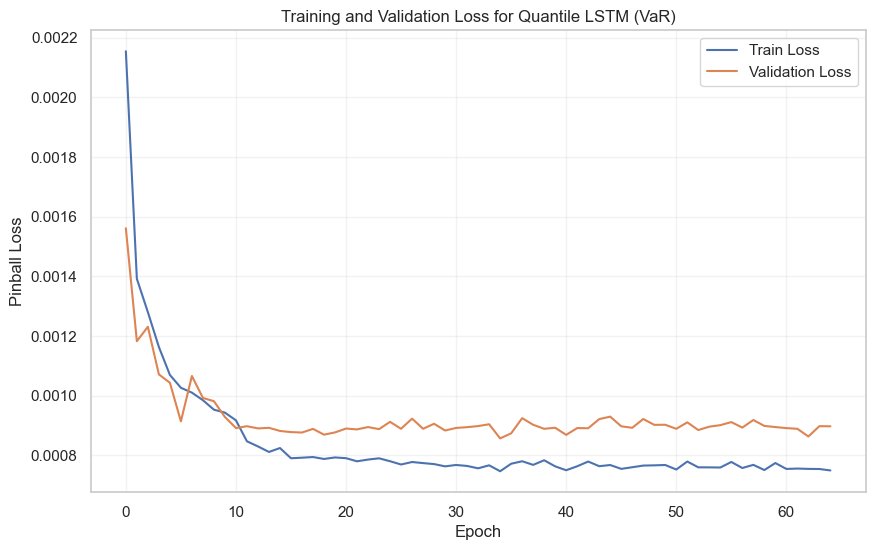

In [9]:
# plot des losses d'entrainement et validation pour le modele VaR
var_history = results["var_history"]
plt.figure(figsize=(10, 6))
plt.plot(var_history["train_loss"], label="Train Loss")
plt.plot(var_history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Pinball Loss")
plt.title("Training and Validation Loss for Quantile LSTM (VaR)")
plt.legend()

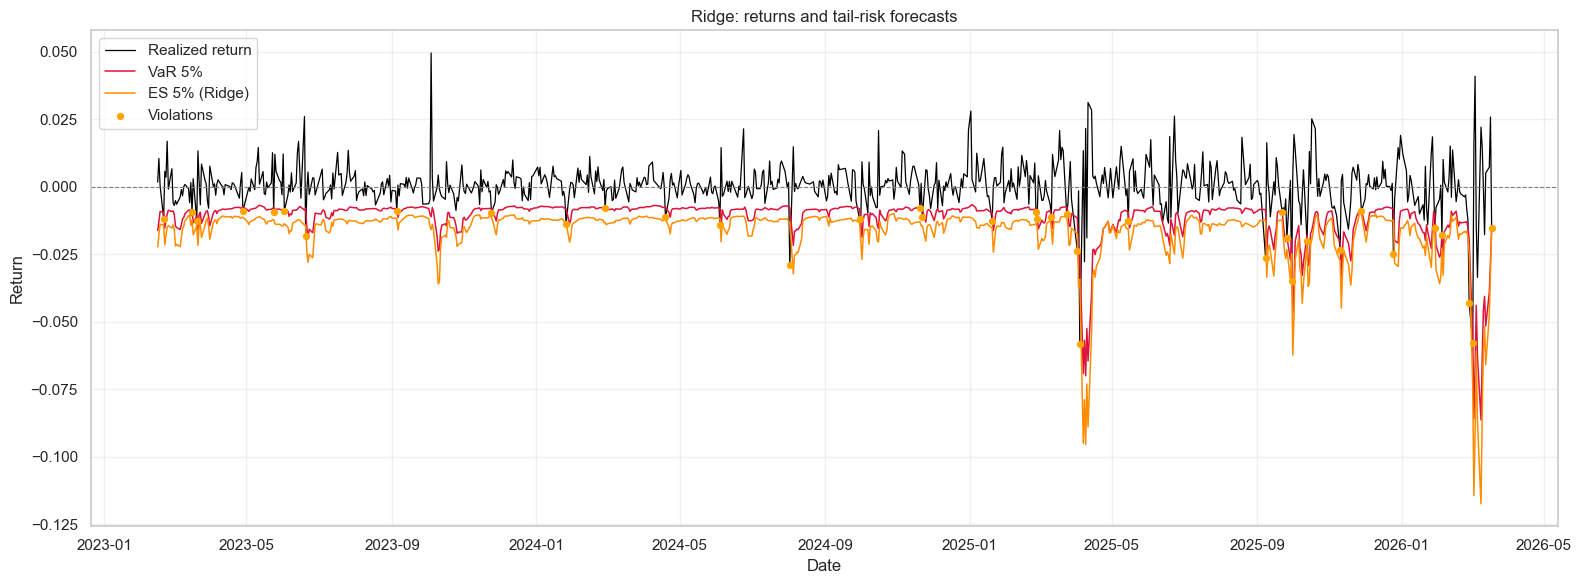

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

plot_df = results["test_predictions"].copy()
plot_df["date"] = pd.to_datetime(plot_df["date"])

plt.figure(figsize=(16, 6))

plt.plot(
    plot_df["date"],
    plot_df["realized_return"],
    color="black",
    linewidth=0.9,
    label="Realized return",
)

plt.plot(
    plot_df["date"],
    plot_df["var_pred"],
    color="crimson",
    linewidth=1.1,
    label="VaR 5%",
)

plt.plot(
    plot_df["date"],
    plot_df["es_pred_ridge"],
    color="darkorange",
    linewidth=1.1,
    label="ES 5% (Ridge)",
)

viol = plot_df["violation"] == 1
plt.scatter(
    plot_df.loc[viol, "date"],
    plot_df.loc[viol, "realized_return"],
    color="orange",
    s=18,
    zorder=5,
    label="Violations",
)

plt.axhline(0.0, color="gray", linestyle="--", linewidth=0.8)
plt.title("Ridge: returns and tail-risk forecasts")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [11]:
if "forecast_results" not in globals():
    forecast_results = build_forecast_results_from_pipeline(results)

forecast_results = forecast_results[forecast_results["model_family"] == "deep_lstm_es_ridge"].copy()
risk_backtest_summary = backtest_forecast_results(forecast_results, alpha=config.alpha)

print("\n===== Risk Backtest Summary =====")
print(risk_backtest_summary)


===== Risk Backtest Summary =====
         model_family  n_observations  n_var_violations  violation_rate  expected_violation_rate  kupiec_pof_stat  kupiec_pof_p_value  \
0  deep_lstm_es_ridge             764                38        0.049738                     0.05         0.001104            0.973493   

   christoffersen_independence_stat  christoffersen_independence_p_value  christoffersen_cc_stat  christoffersen_cc_p_value  n_es_tail_observations  \
0                          0.014482                             0.904212                0.015586                   0.992237                      38   

   es_tail_calibration_stat  es_tail_calibration_p_value  es_tail_residual_mean  
0                 -0.396686                     0.693878              -0.000492  


In [12]:
# =========================================================
# Detection de regimes HMM propre
# Fit HMM uniquement sur la periode train LSTM
# Sortie : regime_df avec regime filtre et regime_for_decision
# =========================================================

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM

REGIME_N_STATES = 2
REGIME_RANDOM_STATE = 42

# =========================================================
# Meme split que le LSTM
# =========================================================

if "df_test" in globals() and "date" in df_test.columns:
    test_start_date = pd.to_datetime(df_test["date"].min())
else:
    test_start_date = pd.Timestamp("2023-02-15")

# =========================================================
# Construction de la base HMM
# =========================================================

required_cols = [
    "date",
    "log_return",
    "log_return_std_21",
    "log_return_mean_21",
]

missing_cols = [col for col in required_cols if col not in df_features.columns]

if missing_cols:
    raise KeyError(f"Colonnes manquantes dans df_features : {missing_cols}")

regime_df = df_features[required_cols].copy()

regime_df = regime_df.rename(
    columns={
        "log_return": "r_t",
        "log_return_std_21": "RV21_t",
        "log_return_mean_21": "MOM21_t",
    }
)

regime_df["date"] = pd.to_datetime(regime_df["date"])
regime_df["r_t"] = pd.to_numeric(regime_df["r_t"], errors="coerce")
regime_df["RV21_t"] = pd.to_numeric(regime_df["RV21_t"], errors="coerce")
regime_df["MOM21_t"] = pd.to_numeric(regime_df["MOM21_t"], errors="coerce")

# =========================================================
# Variables d'etat connues avant le rendement de la date t
# =========================================================
# X_t = [RV21_{t-1}, MOM21_{t-1}]
# Donc le regime associe a t est construit avec des variables laggees.

regime_df["RV21_lag1"] = regime_df["RV21_t"].shift(1)
regime_df["MOM21_lag1"] = regime_df["MOM21_t"].shift(1)

regime_features = ["RV21_lag1", "MOM21_lag1"]

regime_df = (
    regime_df
    .dropna(subset=["date", "r_t"] + regime_features)
    .sort_values("date")
    .reset_index(drop=True)
)

train_mask = regime_df["date"].lt(test_start_date)
test_mask = regime_df["date"].ge(test_start_date)

if train_mask.sum() < 200:
    raise ValueError(
        f"Train HMM trop court : {train_mask.sum()} observations. "
        "Verifie test_start_date ou le split LSTM."
    )

if test_mask.sum() == 0:
    raise ValueError(
        "Aucune observation test HMM. Verifie test_start_date."
    )

# =========================================================
# Standardisation : fit sur train uniquement
# =========================================================

X_train = regime_df.loc[train_mask, regime_features].to_numpy()
X_all = regime_df[regime_features].to_numpy()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_all_scaled = scaler.transform(X_all)

# =========================================================
# Fit HMM uniquement sur train LSTM
# =========================================================

hmm_model = GaussianHMM(
    n_components=REGIME_N_STATES,
    covariance_type="full",
    n_iter=1000,
    random_state=REGIME_RANDOM_STATE,
)

hmm_model.fit(X_train_scaled)

# =========================================================
# Relabellisation economique des etats
# Etat 0 = normal / faible volatilite
# Etat 1 = stress / forte volatilite
# Basee uniquement sur les moyennes apprises sur train
# =========================================================

rv_mean_by_raw_state = hmm_model.means_[:, 0]
raw_state_order = np.argsort(rv_mean_by_raw_state)

raw_to_economic = {
    int(raw_state_order[0]): 0,
    int(raw_state_order[1]): 1,
}

# =========================================================
# Filtrage sequentiel sans utiliser le futur
# =========================================================
# Pour chaque date i :
# - regime_i utilise X_1,...,X_i avec parametres fixes appris sur train.
# - regime_for_decision_i utilise X_1,...,X_{i-1}.
#
# Donc pour une allocation a la date t, il faut utiliser regime_for_decision.
# =========================================================

regime_filtered_raw = []
regime_for_decision_raw = []

for i in range(len(regime_df)):
    # Regime filtre de la date i : disponible apres observation de X_i
    _, posterior_current = hmm_model.score_samples(X_all_scaled[: i + 1])
    current_raw_state = int(np.argmax(posterior_current[-1]))
    regime_filtered_raw.append(current_raw_state)

    # Regime de decision de la date i : seulement information jusqu'a i-1
    if i == 0:
        regime_for_decision_raw.append(np.nan)
    else:
        _, posterior_past = hmm_model.score_samples(X_all_scaled[:i])
        decision_raw_state = int(np.argmax(posterior_past[-1]))
        regime_for_decision_raw.append(decision_raw_state)

regime_df["regime_raw"] = regime_filtered_raw
regime_df["regime"] = regime_df["regime_raw"].map(raw_to_economic).astype("Int64")

regime_df["regime_for_decision_raw"] = regime_for_decision_raw
regime_df["regime_for_decision"] = (
    regime_df["regime_for_decision_raw"]
    .map(raw_to_economic)
    .astype("Int64")
)

# =========================================================
# Labels economiques sans erreur dtype
# =========================================================

regime_df["economic_label"] = pd.Series(
    pd.NA,
    index=regime_df.index,
    dtype="object",
)

regime_df.loc[
    regime_df["regime"].eq(0),
    "economic_label",
] = "normal / faible volatilite"

regime_df.loc[
    regime_df["regime"].eq(1),
    "economic_label",
] = "stress / forte volatilite"


regime_df["economic_label_for_decision"] = pd.Series(
    pd.NA,
    index=regime_df.index,
    dtype="object",
)

regime_df.loc[
    regime_df["regime_for_decision"].eq(0),
    "economic_label_for_decision",
] = "normal / faible volatilite"

regime_df.loc[
    regime_df["regime_for_decision"].eq(1),
    "economic_label_for_decision",
] = "stress / forte volatilite"

# =========================================================
# Resume minimal de verification
# =========================================================

print("HMM fit uniquement sur train LSTM")
print("Date debut test :", test_start_date)
print("Observations train HMM :", int(train_mask.sum()))
print("Observations test HMM :", int(test_mask.sum()))
print("Features HMM :", regime_features)
print("Mapping raw -> economic :", raw_to_economic)

display(
    regime_df[
        [
            "date",
            "r_t",
            "RV21_lag1",
            "MOM21_lag1",
            "regime",
            "economic_label",
            "regime_for_decision",
            "economic_label_for_decision",
        ]
    ].head()
)

display(
    regime_df[
        [
            "date",
            "r_t",
            "RV21_lag1",
            "MOM21_lag1",
            "regime",
            "economic_label",
            "regime_for_decision",
            "economic_label_for_decision",
        ]
    ].tail()
)

HMM fit uniquement sur train LSTM
Date debut test : 2023-02-15 00:00:00
Observations train HMM : 3997
Observations test HMM : 765
Features HMM : ['RV21_lag1', 'MOM21_lag1']
Mapping raw -> economic : {1: 0, 0: 1}


,date,r_t,RV21_lag1,MOM21_lag1,regime,economic_label,regime_for_decision,economic_label_for_decision
0,2007-02-02,0.005631,0.010312,0.003506,1,stress / forte volatilite,<NA>,<NA>
1,2007-02-05,0.004561,0.009991,0.003063,1,stress / forte volatilite,1,stress / forte volatilite
2,2007-02-06,0.010379,0.009556,0.002520,1,stress / forte volatilite,1,stress / forte volatilite
3,2007-02-07,-0.005498,0.009267,0.002275,1,stress / forte volatilite,1,stress / forte volatilite
4,2007-02-08,0.002621,0.009280,0.001583,1,stress / forte volatilite,1,stress / forte volatilite


,date,r_t,RV21_lag1,MOM21_lag1,regime,economic_label,regime_for_decision,economic_label_for_decision
4757,2026-03-13,-0.017755,0.022006,-0.003240,1,stress / forte volatilite,1,stress / forte volatilite
4758,2026-03-16,0.005129,0.021803,-0.004805,1,stress / forte volatilite,1,stress / forte volatilite
4759,2026-03-17,0.007216,0.021911,-0.004376,1,stress / forte volatilite,1,stress / forte volatilite
4760,2026-03-18,0.025839,0.021692,-0.004680,1,stress / forte volatilite,1,stress / forte volatilite
4761,2026-03-19,-0.015441,0.022688,-0.003187,1,stress / forte volatilite,1,stress / forte volatilite


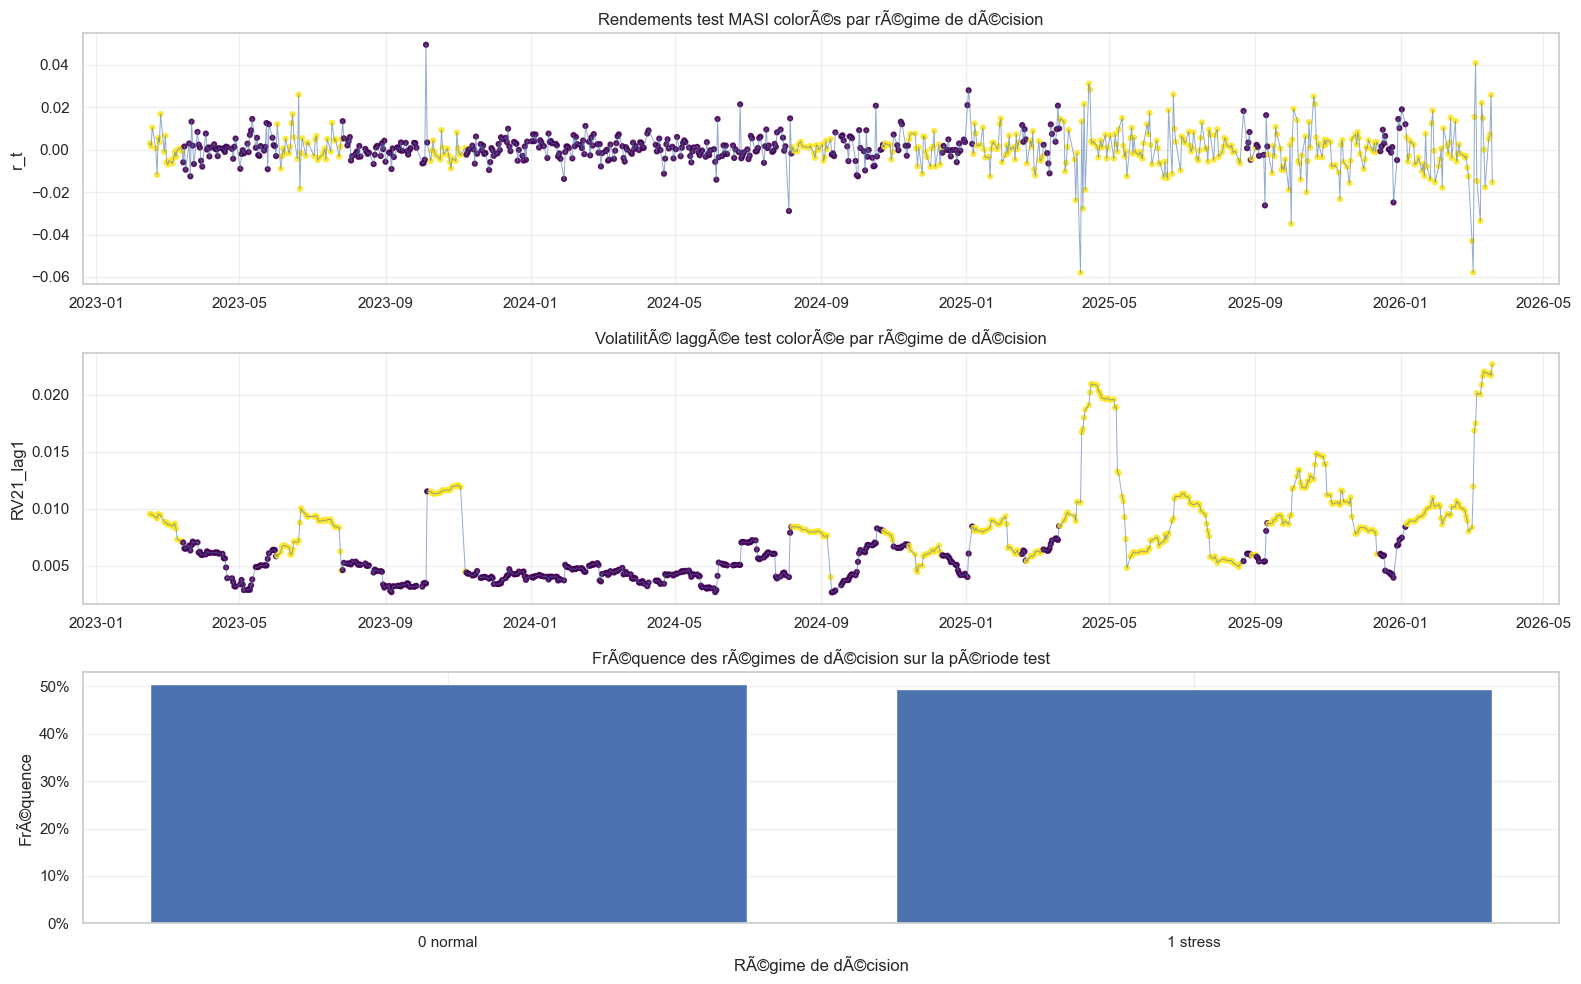

In [13]:
# =========================================================
# Plot uniquement sur la pÃ©riode test out-of-sample
# Sans erreur d'axe date/catÃ©gorie
# =========================================================

plot_regime_df = regime_df.copy()
plot_regime_df["date"] = pd.to_datetime(plot_regime_df["date"])

plot_regime_df = plot_regime_df[
    plot_regime_df["date"].ge(test_start_date)
].copy()

plot_regime_df = plot_regime_df.dropna(
    subset=["regime_for_decision"]
).copy()

plot_regime_df["regime_for_decision"] = (
    plot_regime_df["regime_for_decision"].astype(int)
)

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=False)

axes[0].plot(
    plot_regime_df["date"],
    plot_regime_df["r_t"],
    linewidth=0.7,
    alpha=0.6,
)

axes[0].scatter(
    plot_regime_df["date"],
    plot_regime_df["r_t"],
    c=plot_regime_df["regime_for_decision"],
    cmap="viridis",
    s=12,
    alpha=0.85,
)

axes[0].set_title("Rendements test MASI colorÃ©s par rÃ©gime de dÃ©cision")
axes[0].set_ylabel("r_t")
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    plot_regime_df["date"],
    plot_regime_df["RV21_lag1"],
    linewidth=0.7,
    alpha=0.6,
)

axes[1].scatter(
    plot_regime_df["date"],
    plot_regime_df["RV21_lag1"],
    c=plot_regime_df["regime_for_decision"],
    cmap="viridis",
    s=12,
    alpha=0.85,
)

axes[1].set_title("VolatilitÃ© laggÃ©e test colorÃ©e par rÃ©gime de dÃ©cision")
axes[1].set_ylabel("RV21_lag1")
axes[1].grid(True, alpha=0.3)

regime_counts = (
    plot_regime_df["regime_for_decision"]
    .value_counts(normalize=True)
    .sort_index()
)

axes[2].bar(
    regime_counts.index.astype(int),
    regime_counts.values,
)

axes[2].set_title("FrÃ©quence des rÃ©gimes de dÃ©cision sur la pÃ©riode test")
axes[2].set_xlabel("RÃ©gime de dÃ©cision")
axes[2].set_ylabel("FrÃ©quence")
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(["0 normal", "1 stress"])
axes[2].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0%}")
)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

economique evaluation

In [14]:
from src.analysis.economic_evaluation import (
    align_inputs,
    annualized_return_from_wealth,
    annualized_volatility,
    calmar_ratio,
    cumulative_wealth,
    drawdown_from_wealth,
    evaluate_strategy,
    max_drawdown,
    sharpe_ratio,
    simple_returns_from_log,
    sortino_ratio,
    strategy_simple_returns,
)


In [15]:
from src.analysis.economic_evaluation import (
    compute_weights_from_budget_and_var,
    positive_var,
    rolling_var_quantiles,
    weights_benchmark_econometric,
    weights_hmm_lstm_quantile_budget,
    weights_lstm,
)


## Final Economic Evaluation

The helper functions are imported from `src.analysis.economic_evaluation`. The cells below keep the actual result generation in the notebook so GitHub readers can see the final tables and plots directly.


===== Economic evaluation summary =====


,n_observations,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,final_wealth,average_turnover,average_weight
strategy_name,,,,,,,,,,
Buy_and_hold,703,0.182711,0.138106,1.297553,1.592810,-0.189500,0.964172,1.604975,0.000000,1.000000
HMM_LSTM_budget_quantile,703,0.171148,0.099520,1.655629,2.395439,-0.123684,1.383755,1.561647,0.060783,0.848953


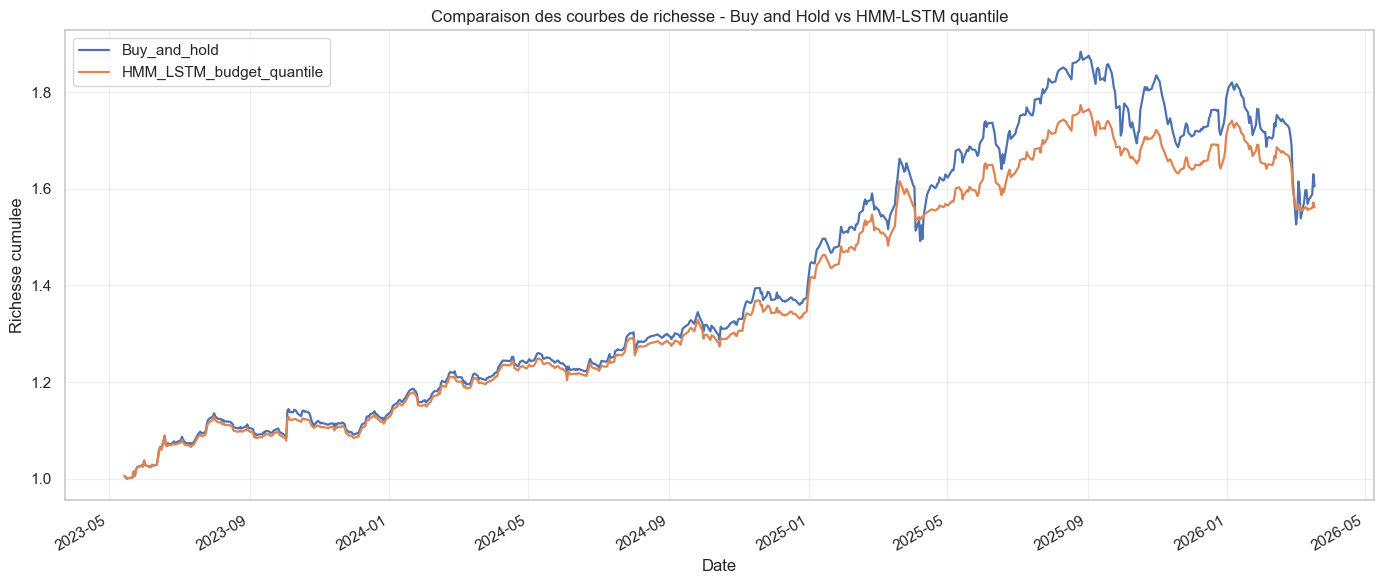

In [16]:
# =========================================================
# Execution de l'evaluation economique Buy and Hold et HMM-LSTM
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TRANSACTION_COST = 0.0
WEIGHT_LAG = 1
PERIODS_PER_YEAR = 252

if "results" not in globals() or "test_predictions" not in results:
    raise NameError("La variable results['test_predictions'] doit etre disponible avant cette cellule.")

if "regime_df" not in globals():
    raise NameError("La variable regime_df doit etre disponible avant l'evaluation HMM-LSTM.")

# =========================
# Base LSTM test period
# =========================
lstm_eval_df = results["test_predictions"].copy()
lstm_eval_df["date"] = pd.to_datetime(lstm_eval_df["date"])
lstm_eval_df = lstm_eval_df.sort_values("date").set_index("date")

lstm_log_returns = pd.to_numeric(lstm_eval_df["realized_return"], errors="coerce")
lstm_var_forecast = pd.to_numeric(lstm_eval_df["var_pred"], errors="coerce")

# =========================
# Regime data alignment
# =========================
regime_eval_df = regime_df.copy()
regime_eval_df["date"] = pd.to_datetime(regime_eval_df["date"])
regime_eval_df = regime_eval_df.sort_values("date").set_index("date")

if "regime_for_decision" not in regime_eval_df.columns:
    raise KeyError("La colonne regime_for_decision est absente de regime_df.")

stress_flag = (
    regime_eval_df["regime_for_decision"]
    .reindex(lstm_var_forecast.index)
    .fillna(0)
    .astype(int)
    .eq(1)
)

# =========================
# HMM-LSTM quantile-budget strategy
# =========================
hmm_lstm_weight_frame = weights_hmm_lstm_quantile_budget(
    lstm_var_forecast=lstm_var_forecast,
    stress_flag=stress_flag,
    window=60,
    q_stress=0.30,
    q_normal=0.70,
    cap=1.0,
    floor=0.0,
)

hmm_lstm_summary, hmm_lstm_details = evaluate_strategy(
    log_returns=lstm_log_returns,
    weights=hmm_lstm_weight_frame["weight"],
    rf=0.0,
    transaction_cost=TRANSACTION_COST,
    weight_lag=WEIGHT_LAG,
    periods_per_year=PERIODS_PER_YEAR,
    strategy_name="HMM_LSTM_budget_quantile",
)

# =========================
# Buy and Hold aligned on same period
# =========================
common_index = hmm_lstm_details.index

buy_hold_log_returns = lstm_log_returns.reindex(common_index)
buy_hold_weights = pd.Series(1.0, index=common_index, name="weight")

buy_hold_summary, buy_hold_details = evaluate_strategy(
    log_returns=buy_hold_log_returns,
    weights=buy_hold_weights,
    rf=0.0,
    transaction_cost=TRANSACTION_COST,
    weight_lag=0,
    periods_per_year=PERIODS_PER_YEAR,
    strategy_name="Buy_and_hold",
)

# =========================
# Summary table
# =========================
economic_summary = pd.DataFrame(
    [buy_hold_summary, hmm_lstm_summary]
).set_index("strategy_name")

strategy_details = {
    "Buy_and_hold": buy_hold_details,
    "HMM_LSTM_budget_quantile": hmm_lstm_details,
}

print("===== Economic evaluation summary =====")
display(economic_summary)

# =========================
# Wealth curves plot
# =========================
wealth_curves = pd.DataFrame({
    name: details["wealth"] for name, details in strategy_details.items()
}).dropna(how="all")

ax = wealth_curves.plot(figsize=(14, 6), linewidth=1.6)
ax.set_title("Comparaison des courbes de richesse - Buy and Hold vs HMM-LSTM quantile")
ax.set_xlabel("Date")
ax.set_ylabel("Richesse cumulee")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [17]:
# =========================================================
# Tableau simplifie des metriques economiques - EDA multivarie
# =========================================================

economic_metrics_table = economic_summary.copy()

economic_metrics_table = economic_metrics_table[
    [
        "n_observations",
        "annualized_return",
        "sharpe_ratio",
        "max_drawdown",
        "final_wealth",
    ]
]

economic_metrics_table_rounded = economic_metrics_table.copy()

economic_metrics_table_rounded["annualized_return"] = (
    economic_metrics_table_rounded["annualized_return"] * 100
)

economic_metrics_table_rounded["max_drawdown"] = (
    economic_metrics_table_rounded["max_drawdown"] * 100
)

economic_metrics_table_rounded = economic_metrics_table_rounded.rename(
    columns={
        "n_observations": "Observations",
        "annualized_return": "Rendement annualise (%)",
        "sharpe_ratio": "Sharpe ratio",
        "max_drawdown": "Max drawdown (%)",
        "final_wealth": "Richesse finale",
    }
)

economic_metrics_table_rounded = economic_metrics_table_rounded.round(4)

display(economic_metrics_table_rounded)


,Observations,Rendement annualise (%),Sharpe ratio,Max drawdown (%),Richesse finale
strategy_name,,,,,
Buy_and_hold,703,18.2711,1.2976,-18.9500,1.6050
HMM_LSTM_budget_quantile,703,17.1148,1.6556,-12.3684,1.5616
